In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.special import expit  # Sigmoid function

def analyze_mc_convergen(x_star, w_map, H, m_list=[10, 100, 1000, 10000], n_runs=50, random_seed=0):
    """
    Monte Carlo convergence analysis for Bayesian predictive probability with Laplace approximation.
    
    Parameters
    ----------
    x_star : np.ndarray
        Test point features, shape (d,)
    w_map : np.ndarray
        MAP weights, shape (d,)
    H : np.ndarray
        Hessian at MAP, shape (d,d)
    m_list : list of int
        List of Monte Carlo sample sizes to test
    n_runs : int
        Number of repeated Monte Carlo runs per m
    random_seed : int
        Seed for reproducibility
    """
    np.random.seed(random_seed)
    d = w_map.shape[0]

    # Compute posterior covariance from Hessian
    cov = np.linalg.inv(H)

    # Store empirical standard deviations
    stds = []

    for m in m_list:
        estimates = np.zeros(n_runs)
        for run in range(n_runs):
            # Sample w_i ~ N(w_map, H^{-1})
            w_samples = multivariate_normal.rvs(mean=w_map, cov=cov, size=m)
            if m == 1:
                w_samples = w_samples[np.newaxis, :]  # Handle case m=1

            # Compute MC estimate
            sigma_vals = expit(w_samples @ x_star)  # shape (m,)
            p_hat = np.mean(sigma_vals)
            estimates[run] = p_hat

        # Empirical std
        stds.append(np.std(estimates))
        print(f"m = {m}, empirical std = {stds[-1]:.5f}")

    # Plot std vs m on log-log scale
    plt.figure(figsize=(6,4))
    plt.plot(m_list, stds, 'o-', label='Empirical Std')
    # Plot reference line for 1/sqrt(m) scaling
    ref_line = stds[0] * np.sqrt(m_list[0]/np.array(m_list))
    plt.plot(m_list, ref_line, '--', label=r'$1/\sqrt{m}$ reference')
    plt.xlabel("Number of Monte Carlo samples m")
    plt.ylabel("Empirical standard deviation of p_hat")
    plt.title("Monte Carlo Convergence (Laplace Approximation)")
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()
    plt.figure(figsize=(6,4))
    plt.loglog(m_list, stds, 'o-', label='Empirical Std')
    # Plot reference line for 1/sqrt(m) scaling
    ref_line = stds[0] * np.sqrt(m_list[0]/np.array(m_list))
    plt.loglog(m_list, ref_line, '--', label=r'$1/\sqrt{m}$ reference')
    plt.xlabel("Number of Monte Carlo samples m")
    plt.ylabel("Empirical standard deviation of p_hat")
    plt.title("Monte Carlo Convergence (Laplace Approximation)")
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()
    


m = 10, empirical std = 0.05127
m = 100, empirical std = 0.02040
m = 1000, empirical std = 0.00629
m = 10000, empirical std = 0.00227


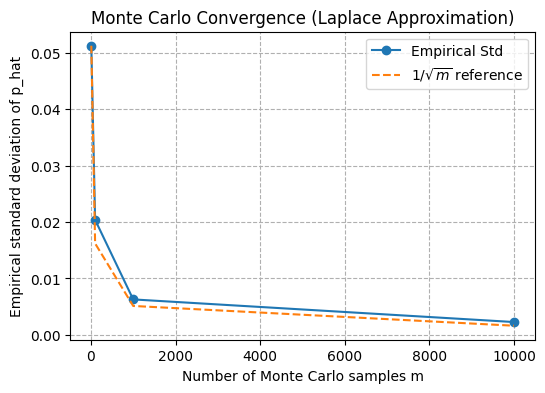

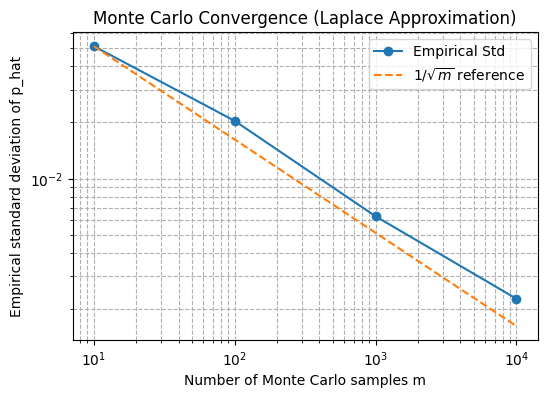

In [6]:
# Example with 5-dimensional test point
d = 5
x_star = np.random.randn(d)
w_map = np.random.randn(d)
H = np.eye(d)  # Simple identity Hessian for demo

analyze_mc_convergen(x_star, w_map, H)
